In [1]:
import os  #basic libraries
from pathlib import Path
from collections import Counter
import pandas as pd  #data handling
import numpy as np
import matplotlib.pyplot as plt  #Visualization
import seaborn as sns
from PIL import Image  #Image handling
import random  #import cv2

sns.set(style="whitegrid")  #plot style

In [2]:
BASE_DIR = Path (r"/content/drive/MyDrive/final project/RiceLeaf disease detection/Data")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:


if not BASE_DIR.exists():
  raise FileNotFoundError(f"BASE_DIR not found: {BASE_DIR}")

classes = sorted([d.name for d in BASE_DIR.iterdir() if d.is_dir()])
print("classes found:", classes)

ALLOWED = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
cls_counts = {}

for cls in classes:
  files = [f for f in (BASE_DIR/cls).iterdir() if f.suffix.lower() in ALLOWED]
  cls_counts[cls] = len(files)

#convert to dataframe
df_counts = pd.DataFrame.from_dict(cls_counts, orient = "index", columns = ["count"])
df_counts

classes found: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


,count
Bacterial leaf blight,40
Brown spot,40
Leaf smut,39


<function matplotlib.pyplot.show(close=None, block=None)>

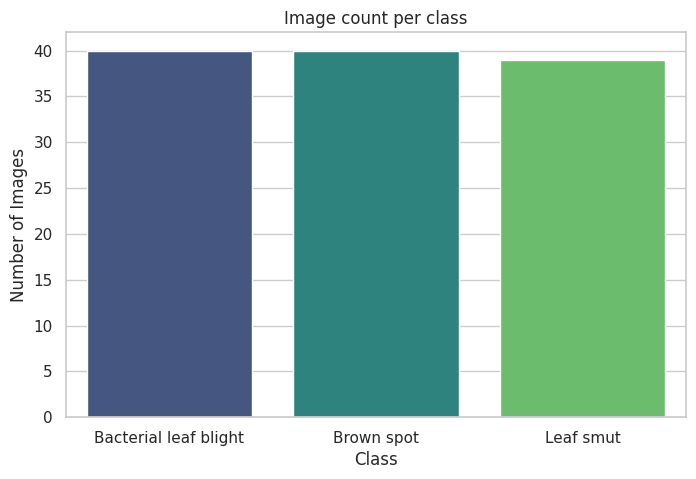

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(x=df_counts.index, y=df_counts["count"], hue=df_counts.index,legend=False, palette="viridis")
plt.title("Image count per class")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.show

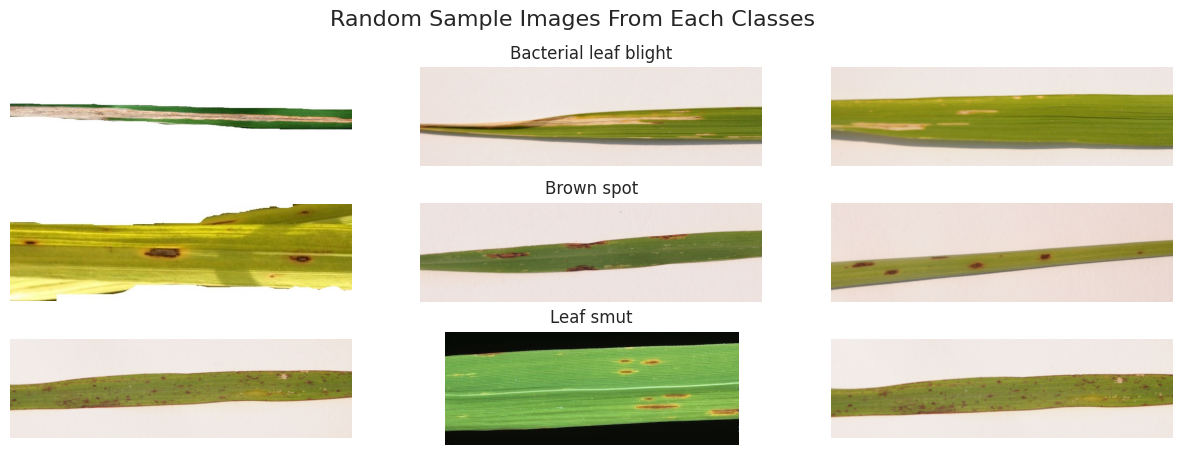

In [6]:
def show_sample_images(BASE_DIR, classes, samples_per_class=3):
  plt.figure(figsize=(15,5))

  for i, cls in enumerate(classes):
    files = list((BASE_DIR/cls).glob("*"))
    for j in range(samples_per_class):
      img_path = random.choice(files)
      img = Image.open(img_path)

      plt.subplot(len(classes), samples_per_class, i*samples_per_class + j + 1)
      plt.imshow(img)
      plt.axis("off")
      if j == 1:
        plt.title(cls)

  plt.suptitle("Random Sample Images From Each Classes", fontsize=16)
  plt.show()

show_sample_images(BASE_DIR, classes, samples_per_class=3)

In [7]:
ALLOWED = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
image_info = []

for cls in classes:
  files = [f for f in (BASE_DIR/cls).iterdir() if f.suffix.lower() in ALLOWED]
  for f in files[:500]:  #limit for speed
     img = Image.open(f)
     image_info.append({'img_path': str(BASE_DIR/cls), "class": cls, "width": img.width, "height": img.height, "format": img.format, "mode" : img.mode, 'is_corrupt': False})

df_img = pd.DataFrame(image_info)
df_img.head()

,img_path,class,width,height,format,mode,is_corrupt
0,/content/drive/MyDrive/final project/RiceLeaf ...,Bacterial leaf blight,3081,897,JPEG,RGB,False
1,/content/drive/MyDrive/final project/RiceLeaf ...,Bacterial leaf blight,3081,897,JPEG,RGB,False
2,/content/drive/MyDrive/final project/RiceLeaf ...,Bacterial leaf blight,3081,897,JPEG,RGB,False
3,/content/drive/MyDrive/final project/RiceLeaf ...,Bacterial leaf blight,3081,897,JPEG,RGB,False
4,/content/drive/MyDrive/final project/RiceLeaf ...,Bacterial leaf blight,3081,897,JPEG,RGB,False


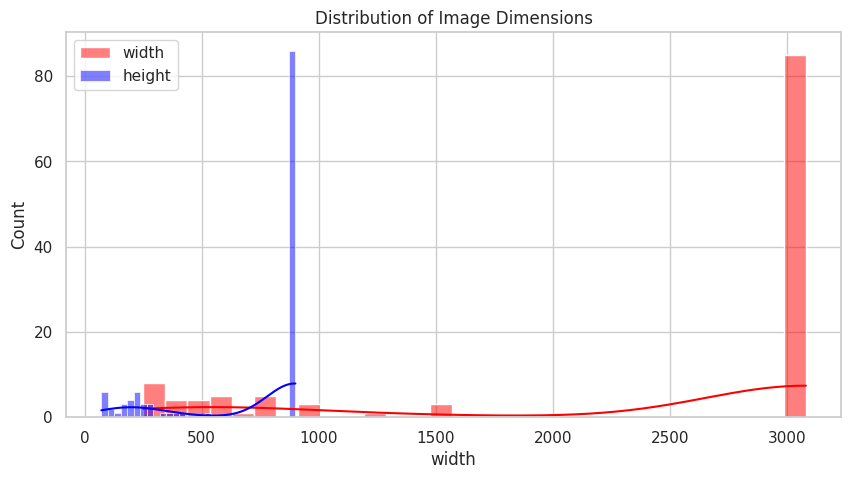

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df_img["width"], bins=30, kde=True, color="red", label="width")
sns.histplot(df_img["height"], bins=30, kde=True, color="blue", label="height")
plt.legend()
plt.title("Distribution of Image Dimensions")
plt.show()

In [9]:
#function to comute mean RGB
def get_color_means(img_path):
  try:
    with Image.open(img_path).convert("RGB") as img:
      arr = np.array(img)
      return arr.mean(axis=(0,1)) #RGB
  except Exception as e:
    print(f"Error reading {img_path}: {e}")
    return None

In [10]:
#collect stats
color_stats=[]
for cls in classes:
  files = [f for f in (BASE_DIR/cls).iterdir() if f.suffix.lower() in ALLOWED][:50]
  for f in files:
    means = get_color_means(f)
    if means is not None:
      color_stats.append({"class": cls, "R": means[0], "G": means[1], "B": means[2]})
df_colors = pd.DataFrame(color_stats)
print(df_colors.head())

                   class           R           G           B
0  Bacterial leaf blight  196.812530  187.389357  163.829316
1  Bacterial leaf blight  197.497048  191.259583  163.422926
2  Bacterial leaf blight  182.225553  175.964424  138.178583
3  Bacterial leaf blight  190.699627  186.265722  143.515217
4  Bacterial leaf blight  182.009223  179.470045  142.295059


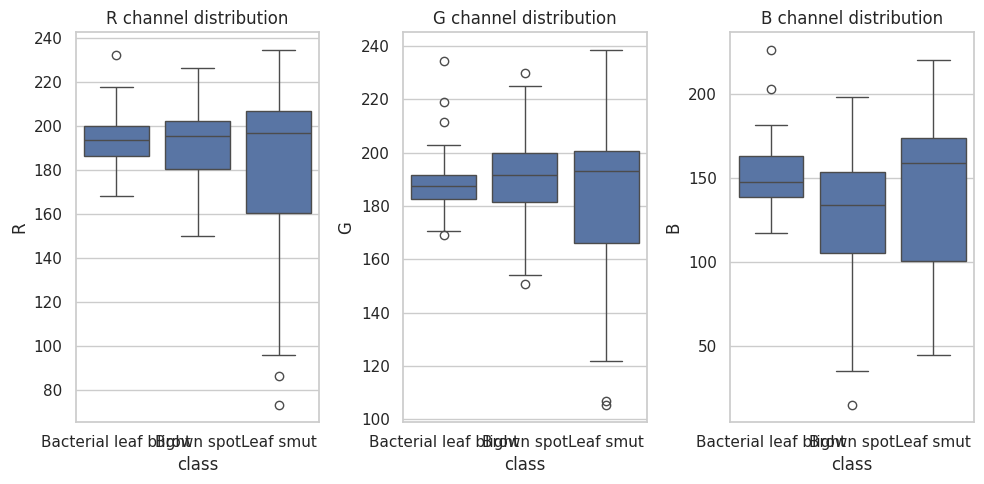

In [11]:
#plot distributions
plt.figure(figsize=(10,5))
for i, channel in enumerate(["R", "G", "B"], 1):
  plt.subplot(1,3,i)
  sns.boxplot(x = "class", y=channel, data=df_colors)
  plt.title(f"{channel} channel distribution")
plt.tight_layout()
plt.show()

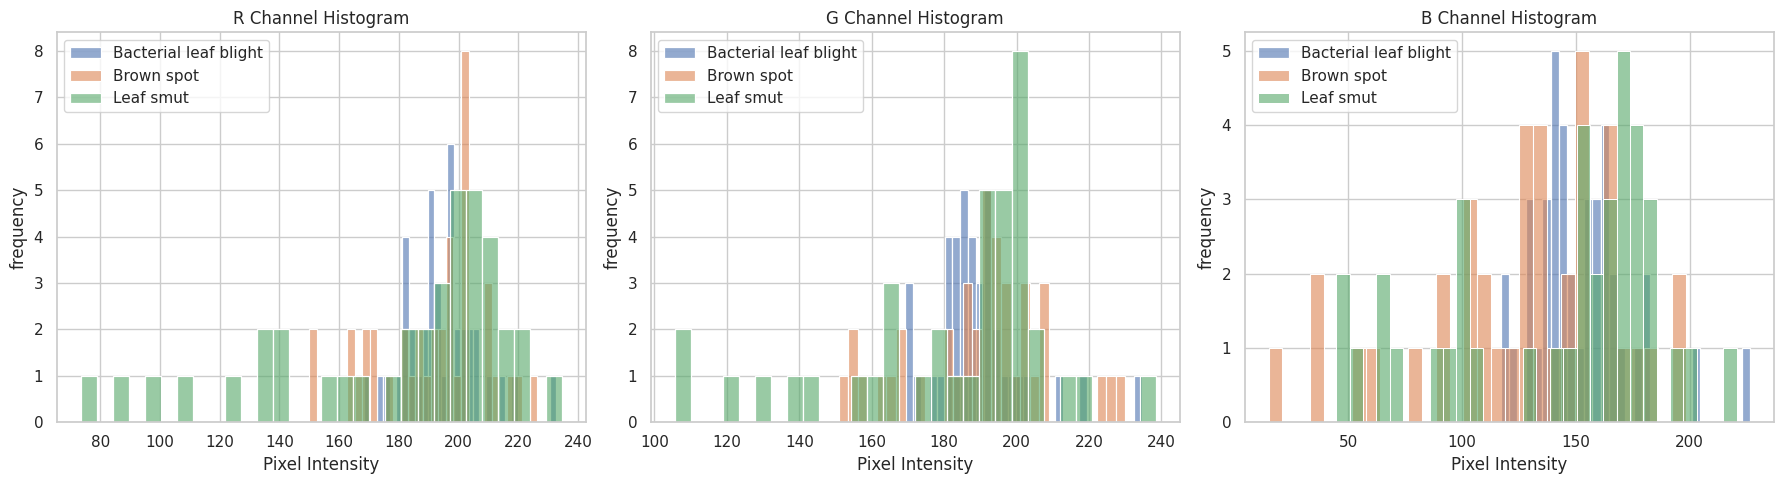

In [12]:
plt.figure(figsize=(18,5))
for i, channel in enumerate(["R", "G", "B"], 1):
  plt.subplot(1,3,i)
  for cls in df_colors["class"].unique():
    sns.histplot(
        df_colors[df_colors["class"] == cls][channel],
        kde=False,
        bins=30,
        alpha=0.6,
        label=cls
    )
  plt.title(f"{channel} Channel Histogram")
  plt.xlabel("Pixel Intensity")
  plt.ylabel("frequency")
  plt.legend()

plt.tight_layout()
plt.show()

In [13]:
import hashlib
from tqdm import tqdm

hashes = {}
dup_rows = []
for p in tqdm(df_img['img_path'].tolist(), desc='Hashing files'):
  try:
    with open(p, 'rb') as f:
      h = hashlib.md5(f.read()).hexdigest()
    if h in hashes:
      dub_rows.append({'img_path': p, 'duplicate_of': hashes[h]})
    else:
      hashes[h] = p
  except Exception:
    continue
print('Exact duplicate count:', len(dup_rows))


Hashing files: 100%|██████████| 119/119 [00:00<00:00, 1768.48it/s]

Exact duplicate count: 0


In [14]:
summary = {
    'total_files': int(df_img.shape[0]),
    'corrupt_files': int(df_img['is_corrupt'].sum()),
    'num_classes': int(len(classes))
}

In [15]:
summary
df_img.to_csv('Rice_Leaf_EDA.csv', index= False)
import json
with open('eda_summary.json','w') as f:
  json.dump(summary, f, indent=2)

In [16]:
print('Saved Rice_leaf_EDA.csv and eda_summary.json')
print('Summary of findings:')
print("Classes detected:", classes)
print("Number of classes:", len(classes))
print("Total images:", df_counts['count'].sum())
print("Class distribution\n:", df_counts)

Saved Rice_leaf_EDA.csv and eda_summary.json
Summary of findings:
Classes detected: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
Number of classes: 3
Total images: 119
Class distribution
:                        count
Bacterial leaf blight     40
Brown spot                40
Leaf smut                 39


In [17]:
#Model building
from tensorflow.keras import backend as K
K.clear_session()

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [18]:
#Configuration
Img_height = 224
Img_width = 224
batch_size=16
epochs_freeze = 20
epochs_fine_tune = 20
num_classes = 3  #types of diseases data
data_dir = r"/content/drive/MyDrive/final project/RiceLeaf disease detection/Data"
K_fold = 5  #number of cross validation

In [19]:
print("Loading images and labels...")
images=[]
labels=[]
class_names=classes # Use the already defined 'classes' variable which correctly lists directories
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i : name for i, name in enumerate(class_names)}

for class_name in class_names:
  class_path = os.path.join(data_dir,class_name)
  if not os.path.isdir(class_path):
    continue

  for img_name in os.listdir(class_path):
    img_path = os.path.join(class_path,img_name)
    try:
      img = tf.keras.preprocessing.image.load_img(img_path, target_size=(Img_height, Img_width))
      img_array = tf.keras.preprocessing.image.img_to_array(img)
      images.append(img_array)
      labels.append(class_to_idx[class_name])
    except Exception as e:
      print(f"Error loading image{img_path}: {e}")
images = np.array(images, dtype='float32')
labels = np.array(labels)
images /= 255.0

print(f"Loaded {len(images)} images.")
print("Class mapping: ", class_to_idx)

Loading images and labels...
Loaded 119 images.
Class mapping:  {'Bacterial leaf blight': 0, 'Brown spot': 1, 'Leaf smut': 2}


In [20]:
#define model creation function(for k-fold)
def build_transfer_model(num_classes):
  base_model = tf.keras.applications.MobileNetV2(input_shape=(Img_height, Img_width, 3), include_top=False, weights='imagenet')
  base_model.trainable = False

  #adding custom classification layers on top
  x= base_model.output
  x=Flatten()(x)
  x=Dense(256, activation ='relu')(x)
  x=BatchNormalization()(x)
  x= Dropout(0.5)(x)
  output = Dense(num_classes, activation='softmax')(x)

  model=Model(inputs=base_model.input, outputs=output)

  return model, base_model

In [21]:
#k-fold cross validation
skf = StratifiedKFold(n_splits=K_fold, shuffle=True, random_state=42)

fold_accuracies=[]
fold_train_accuracies=[]
fold_histories=[]
fold_reports=[]
fold_matrices=[]

for fold, (train_index, val_index) in enumerate(skf.split(images, labels)):
  print(f"\n starting fold {fold+1}/{K_fold}")

  X_train, X_val = images[train_index], images[val_index]
  y_train, y_val = labels[train_index], labels[val_index]

  #one-hot encode labels
  y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes = num_classes)
  y_val_one_hot = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)

  #Rebuild model for each fold to ensure fresh weights
  model, base_model = build_transfer_model(num_classes)

  #stage-1: training only the top model
  print("stage 1: Training top layers (frozen base)")
  model.compile(optimizer=Adam(learning_rate=0.0001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  #data augmentation for training
  train_datagen = ImageDataGenerator(
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest'
  )
  history_stage1=model.fit(
      train_datagen.flow(X_train, y_train_one_hot, batch_size=batch_size),
      steps_per_epoch=len(X_train) // batch_size,
      epochs=epochs_freeze,
      validation_data=(X_val, y_val_one_hot),
      callbacks=[EarlyStopping(monitor='val_loss',patience=5, restore_best_weights=True)],
      verbose=0
  )

  #stage2: fine tunning(unfreeze layers of the base model)
  print("\n stage 2: Fine tuning the entire model")
  base_model.trainable=True #unfreeze the base model

  model.compile(optimizer=Adam(learning_rate=0.00001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])
  history_stage2=model.fit(
      train_datagen.flow(X_train, y_train_one_hot, batch_size=batch_size),
      steps_per_epoch=len(X_train) // batch_size,
      epochs=epochs_fine_tune,
      validation_data=(X_val, y_val_one_hot),
      callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
      verbose=0
  )
   #combine histories for plotting
  combined_history ={k: history_stage1.history.get(k,[]) + history_stage2.history.get(k,[]) for k in set(history_stage1.history) | set(history_stage2.history)}
  fold_histories.append(combined_history)

  #get best training accuracy from both stages
  best_train_acc_stage1 = max(history_stage1.history['accuracy'] + history_stage2.history['accuracy'])
  fold_train_accuracies.append(best_train_acc_stage1)

  #evaluate fold
  print(f"Evaluating fold {fold+1}/{K_fold}")
  loss, accuracy = model.evaluate(X_val, y_val_one_hot, verbose=0)
  print(f"Fold {fold+1} Validation loss: {loss:.4f}")
  print(f"fold {fold+1} Validation accuracy: {accuracy*100:.2f}%")
  fold_accuracies.append(accuracy)

  #generate Classification report and confusion matrix
  y_pred_probs = model.predict(X_val)
  y_pred = np.argmax(y_pred_probs, axis=1)

  report = classification_report(y_val, y_pred, target_names=class_names, output_dict=True)
  fold_reports.append(report)
  print("\nClassification Report:")
  print(classification_report(y_val, y_pred, target_names=class_names))

  cm = confusion_matrix(y_val, y_pred)
  fold_matrices.append(cm)
  print("Confusion Matrix : \n", cm)

print("\n K-fold cross validation results:")
print(f"Individual fold training accuracies: {[f'{a*100:.2f}%' for a in fold_train_accuracies]}")
print(f"Average Validation Accuracy: {np.mean(fold_train_accuracies)*100:.2f}% (+/-{np.std(fold_accuracies)*100:.2f}%)")
print(f"Individual fold validation accuracies : {[f'{a*100:.2f}' for a in fold_accuracies]}")
print(f"Average Validation Accuracy: {np.mean(fold_accuracies)*100:.2f}%(+/-{np.std(fold_train_accuracies)*100:.2f}%)")


 starting fold 1/5
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
stage 1: Training top layers (frozen base)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



 stage 2: Fine tuning the entire model
Evaluating fold 1/5
Fold 1 Validation loss: 0.5076
fold 1 Validation accuracy: 83.33%
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.78      0.88      0.82         8
           Brown spot       0.78      0.88      0.82         8
            Leaf smut       1.00      0.75      0.86         8

             accuracy                           0.83        24
            macro avg       0.85      0.83      0.83        24
         weighted avg       0.85      0.83      0.83        24

Confusion Matrix : 
 [[7 1 0]
 [1 7 0]
 [1 1 6]]

 starting fold 2/5
stage 1: Training top layers (frozen base)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



 stage 2: Fine tuning the entire model
Evaluating fold 2/5
Fold 2 Validation loss: 2.4765
fold 2 Validation accuracy: 54.17%
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.44      1.00      0.62         8
           Brown spot       0.80      0.50      0.62         8
            Leaf smut       1.00      0.12      0.22         8

             accuracy                           0.54        24
            macro avg       0.75      0.54      0.48        24
         weighted avg       0.75      0.54      0.48        24

Confusion Matrix : 
 [[8 0 0]
 [4 4 0]
 [6 1 1]]

 starting fold 3/5
stage 1: Training top layers (frozen base)


...

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



 stage 2: Fine tuning the entire model
Evaluating fold 4/5
Fold 4 Validation loss: 0.3146
fold 4 Validation accuracy: 95.83%
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      1.00      1.00         8
           Brown spot       0.89      1.00      0.94         8
            Leaf smut       1.00      0.88      0.93         8

             accuracy                           0.96        24
            macro avg       0.96      0.96      0.96        24
         weighted avg       0.96      0.96      0.96        24

Confusion Matrix : 
 [[8 0 0]
 [0 8 0]
 [0 1 7]]

 starting fold 5/5
stage 1: Training top layers (frozen base)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



 stage 2: Fine tuning the entire model
Evaluating fold 5/5
Fold 5 Validation loss: 0.5672
fold 5 Validation accuracy: 82.61%


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.88      0.88      0.88         8
           Brown spot       0.75      0.75      0.75         8
            Leaf smut       0.86      0.86      0.86         7

             accuracy                           0.83        23
            macro avg       0.83      0.83      0.83        23
         weighted avg       0.83      0.83      0.83        23

Confusion Matrix : 
 [[7 1 0]
 [1 6 1]
 [0 1 6]]

 K-fold cross validation results:
Individual fold training accuracies: ['93.75%', '100.00%', '100.00%', '93.75%', '94.79%']
Average Validation Accuracy: 96.46% (+/-13.76%)
Individual fold validation accuracies : ['83.33', '54.17', '83.33', '95.83', '82.61']
Average Validation Accuracy: 79.86%(+/-2.92%)


Plotting training and validation metrics for each fold:


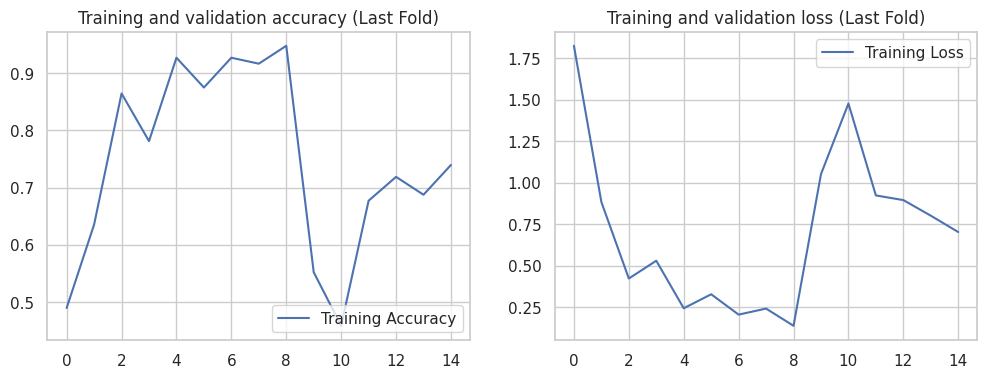

In [23]:
if fold_histories:
  print("Plotting training and validation metrics for each fold:")
  last_history = fold_histories[-1]
  acc = last_history['accuracy']
  val_acc = last_history['val_accuracy']
  loss = last_history['loss']
  val_loss = last_history['val_loss']

  epochs_range = range(len(acc))

  plt.figure(figsize=(12,4))
  plt.subplot(1,2,1)
  plt.plot(epochs_range, acc, label='Training Accuracy')
  plt.legend(loc='lower right')
  plt.title('Training and validation accuracy (Last Fold)')

  plt.subplot(1,2,2)
  plt.plot(epochs_range, loss, label='Training Loss')
  plt.legend(loc='upper right')
  plt.title('Training and validation loss (Last Fold)')

  plt.show()

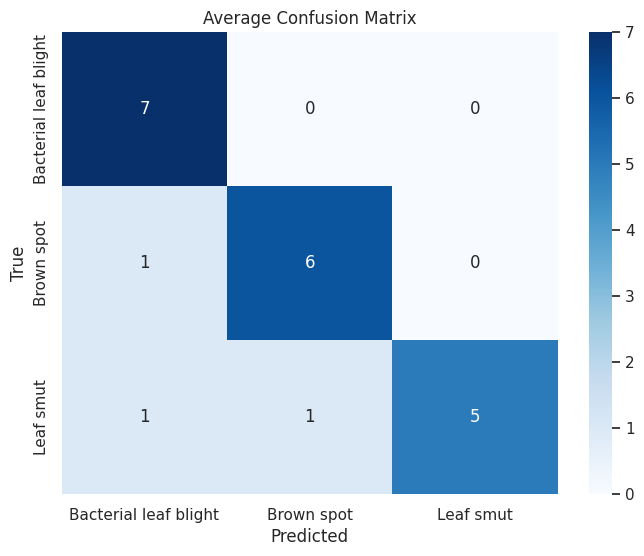

In [24]:
if fold_matrices:
  avg_cm = np.mean(fold_matrices, axis=0).astype(int)
  plt.figure(figsize=(8,6))
  sns.heatmap(avg_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
  plt.title('Average Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.show()

In [25]:
#saving the model
model_save_path = 'rice_leaf-disease_classifier_transfer_learning.h5'
model.save(model_save_path)
print(f"Final model (from last fold) saved to {model_save_path}")

Final model (from last fold) saved to rice_leaf-disease_classifier_transfer_learning.h5


In [26]:
#diagnostics + Interpretability for one test img
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import Bunch

try:
  import cv2
  HAS_CV2 = True
except Exception :
  HAS_CV2 = False
  from PIL import Image

In [52]:
data_dir = (r"/content/drive/MyDrive/final project/RiceLeaf disease detection/Data")
model_path = "rice_leaf-disease_classifier_transfer_learning.h5"
test_image_path = r"/content/drive/MyDrive/final project/RiceLeaf disease detection/Data/test1.jpg"
# Find a sample image in the 'Brown spot' directory
brown_spot_dir = os.path.join(data_dir, 'Brown spot')

# Ensure the directory exists and contains files
if os.path.isdir(brown_spot_dir):
    image_files = [f for f in os.listdir(brown_spot_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    if image_files:
        test_image_path = os.path.join(brown_spot_dir, image_files[0])
    else:
        test_image_path = None
        print(f"No image files found in {brown_spot_dir}")
else:
    test_image_path = None
    print(f"Directory not found: {brown_spot_dir}")


class_names_override = None

print("Loading model:", model_path)
model = load_model(model_path)
print("Model loaded.")

Loading model: rice_leaf-disease_classifier_transfer_learning.h5


Model loaded.


In [53]:
def get_train_class_order(data_dir):
  if not os.path.isdir(data_dir):
    return None
  classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
  return classes
train_class_order = get_train_class_order(data_dir)
if train_class_order is None:
  print(f"No class folders found in {data_dir}.")
else:
  print("class order from training folder (sorted):", train_class_order)

if class_names_override:
  class_names = class_names_override
else:
  class_names = train_class_order if train_class_order is not None else["class0", "class1","class2"]

print("using class_names for interpretation:", class_names)

class order from training folder (sorted): ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
using class_names for interpretation: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [54]:
IMG_H=224
IMG_W=224

def preprocess_for_model(img_path, target_size=(IMG_H, IMG_W)):
  pil = image.load_img(img_path)
  img = image.load_img(img_path, target_size = target_size)
  arr = image.img_to_array(img)
  arr = np.expand_dims(arr, axis=0).astype("float32") / 255.0
  return arr, pil

In [55]:
def predict_and_show(img_path):
  x, orig_pil = preprocess_for_model(img_path)
  preds = model.predict(x)[0]
  print("\nProbabilities (plain) :")
  for cname, p in zip(class_names, preds):
    print(f" {cname:25s}: {p*100:6.2f}%")
  pred_idx = int(np.argmax(preds))
  pred_label = class_names[pred_idx]
  conf = preds[pred_idx]
  #show original image
  plt.figure(figsize=(10,5))
  plt.subplot(1,2,1)
  plt.imshow(orig_pil)
  plt.axis("off")
  plt.title(f"pred: {pred_label} ({conf*100:.2f}%)")

  #Barchart
  plt.subplot(1,2,2)
  plt.bar(class_names, preds)
  plt.ylim(0,1)
  plt.title("Softmax Probabilities (plain)")
  plt.tight_layout()
  plt.show()
  return preds

In [56]:
#40 Test-time augmentation (TTA) averageed prediction
def tta_predict(img_path, tta_steps=20):
  x0, _ =preprocess_for_model(img_path)
  #Image generator with similar augmentations used in training
  datagen = ImageDataGenerator(
      rotation_range=30,
      width_shift_range=0.1,
      height_shift_range=0.1,
      shear_range=0.1,
      zoom_range=0.1,
      horizontal_flip=True,
      fill_mode='nearest'
  )
  gen = datagen.flow(x0,batch_size=1, shuffle=False)
  preds = []
  for i in range(tta_steps):
    batch = next(gen)
    p=model.predict(batch)[0]
    preds.append(p)
  preds = np.array(preds)
  mean_pred = preds.mean(axis=0)
  print(f"\nTTA average over {tta_steps} transforms:")
  for cname, p in zip(class_names, mean_pred):
    print(f"   {cname:25s} : {p*100 : 6.2f}%")
  #bar chart
  plt.figure(figsize=(6,3))
  plt.bar(class_names,mean_pred)
  plt.ylim(0,1)
  plt.title(f"TTA mean probabilities ({tta_steps} steps)")
  plt.show()
  return mean_pred

In [57]:
#visual activation
def find_last_conv_layer(model):
  for layer in reversed(model.layers):
    shape=getattr(layer.output,"shape", None)
    if shape is not None and len(shape) == 4:
      return layer.name
  return None

In [58]:
def make_grandcam_heatmap(img_array, model, last_conv_layer_name, pred_index = None):
  grad_model = tf.keras.models.Model(
      [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
  )
  with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    if pred_index is None:
      pred_index = tf.argmax(predictions[0])
    loss = predictions[:, pred_index]
  grads = tape.gradient(loss, conv_outputs)
  pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
  conv_outputs = conv_outputs[0]
  heatmap = tf.squeeze(tf.linalg.matmul(conv_outputs, pooled_grads[..., tf.newaxis]))
  heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
  return heatmap.numpy()

In [59]:
def show_gradcamp(img_path, preds=None):
  x, orig_pil = preprocess_for_model(img_path)
  if preds is None:
    preds = model.predict(x)[0]
  pred_index = int(np.argmax(preds))
  last_conv = find_last_conv_layer(model)
  if last_conv is None:
    print("No convolutional layer found in the model.")
    return
  print("Using last conv layer:", last_conv)
  heatmap = make_grandcam_heatmap(x, model, last_conv, pred_index)
  heatmap = np.uint8(255 * heatmap) # resixe the heatmap to original image size
  import numpy as np
  orig = np.array(orig_pil)
  heatmap_resized = cv2.resize(heatmap, (orig.shape[1], orig.shape[0])) if HAS_CV2 else np.array(Image.fromarray(heatmap).resize((orig.shape[1], orig.shape[0])))
  if HAS_CV2:
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    superimposed = heatmap_color *0.4 + orig
    superimposed = np.uint8(np.clip(superimposed, 0, 255))
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Grad-CAM : {class_names[pred_index]} ({preds[pred_index]*100:.2f}%)")
    plt.show()
  else:
    plt.figure(figsize=(6,6))
    plt.imshow(orig)
    plt.imshow(heatmap_resized, cmap='jet', alpha=0.4)
    plt.axis("off")
    plt.title(f"Grad-CAM (fallback) : {class_names[pred_index]} ({preds[pred_index]*100:.2f}%)")
    plt.show()


 Plain prediction and image


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Probabilities (plain) :
 Bacterial leaf blight    :   0.70%
 Brown spot               :  99.07%
 Leaf smut                :   0.23%


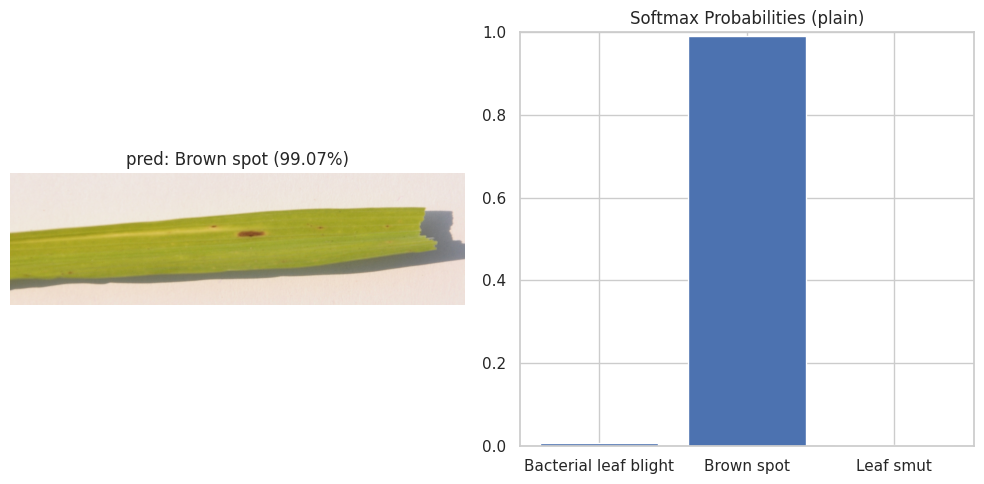


 TTA prediction
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

TTA average over 20 transforms:
   Bacterial leaf blight     :  11.34%
   Brown spot                :  84.56%
   Leaf smut                 :   4.10%


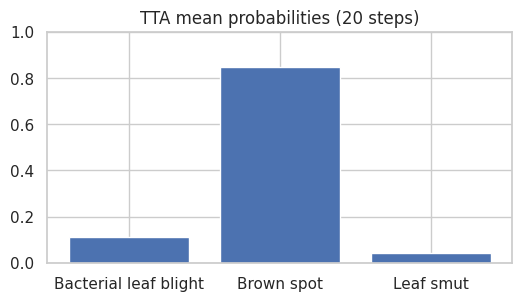


 Grad-CAM visualization
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


UnboundLocalError: cannot access local variable 'np' where it is not associated with a value

In [60]:
print("\n Plain prediction and image")
plain_preds = predict_and_show(test_image_path)

print("\n TTA prediction")
tta_preds = tta_predict(test_image_path, tta_steps = 20)

print("\n Grad-CAM visualization")
show_gradcamp(test_image_path)

print("\n Grad-CAM visualization with TTA predictions")
show_gradcamp(test_image_path, preds=tta_preds)

In [62]:
import pandas as pd

fold_results = {
    "Fold": range(1, len(fold_train_accuracies) + 1),
    "Training Accuracy": [round (a*100, 2) for a in fold_train_accuracies],
    "Validation Accuracy": [round(a*100, 2) for a in fold_accuracies]
}
df_results = pd.DataFrame(fold_results)
df_results

,Fold,Training Accuracy,Validation Accuracy
0,1,93.75,83.33
1,2,100.00,54.17
2,3,100.00,83.33
3,4,93.75,95.83
4,5,94.79,82.61


In [63]:
avg_train = round(np.mean(fold_train_accuracies)*100,2)
avg_val = round(np.mean(fold_accuracies)*100,2)
df_results.loc["Average"] = ["-", avg_train, avg_val]

print(" model performance across folds:")
print(df_results)

 model performance across folds:
        Fold  Training Accuracy  Validation Accuracy
0          1              93.75                83.33
1          2             100.00                54.17
2          3             100.00                83.33
3          4              93.75                95.83
4          5              94.79                82.61
Average    -              96.46                79.86
